In [ ]:
import pandas as pd
import  numpy as np
from sklearn.metrics import mean_absolute_error
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LSTM

In [ ]:
df = pd.read_csv('/home/purushottam/MACHINE LEARNING/TIME SERIES/DATASETS/PJME_hourly.csv')

In [ ]:
df['Datetime'] = pd.to_datetime(df['Datetime'])
df = df.sort_values('Datetime')

In [6]:
df = df[(df['PJME_MW'] >= 20000)]

In [7]:
def window(x,y, window):
    x_seq = []
    y_seq = []

    for i in range(window, len(x)):
        x_seq.append(x[i-window:i])
        y_seq.append(y[i])

    return np.array(x_seq), np.array(y_seq)


In [8]:
def time(df):
    df['Month'] = df['Datetime'].dt.month
    df['Year'] = df['Datetime'].dt.year
    df['Dayofweek'] = df['Datetime'].dt.dayofweek
    df['Dayofyear'] = df['Datetime'].dt.dayofyear
    df['Quarter'] = df['Datetime'].dt.quarter
    return df

def features(df):
    df["Lag 1"] = df['PJME_MW'].shift(1)
    df['Lag 7'] = df['PJME_MW'].shift(7)
    df['Lag 30'] = df['PJME_MW'].shift(30)
    df['MA 7'] = df['PJME_MW'].shift(1).rolling(7).mean()
    df['MA 30'] = df['PJME_MW'].shift(1).rolling(30).mean()
    df['STD 7'] = df['PJME_MW'].shift(1).rolling(7).std()
    df['STD 30'] = df['PJME_MW'].shift(1).rolling(30).std()
    return df

df = time(df)
df = features(df)

df.dropna(inplace = True)

df['Target'] = df['PJME_MW'].shift(-1)

In [9]:
train = df[(df['Datetime'] >= '2002-01-03') & (df['Datetime'] < '2010-01-02')]
val = df[(df['Datetime'] >= '2010-01-02') & (df['Datetime'] < '2014-01-02')]
test = df[(df['Datetime'] >= '2014-01-02') & (df['Datetime'] <= '2018-08-02')]

del train['Datetime']
del val['Datetime']
del test['Datetime']


In [10]:
Features = ['Lag 1', 'Lag 7', 'Lag 30', 'MA 7', 'MA 30', 'STD 7', 'STD 30', 'Month', 'Year', 'Quarter', 'Dayofweek', 'Dayofyear','PJME_MW']
Target = ['Target']

x_train = train[Features]
y_train = train[Target]

x_val = val[Features]
y_val = val[Target]

x_test = test[Features]
y_test = test[Target]

In [11]:
x_mean = x_train.mean()
x_std = x_train.std()

x_train_sc = (x_train - x_mean) / x_std
x_val_sc = (x_val - x_mean) / x_std
x_test_sc = (x_test - x_mean) / x_std

y_mean= y_train.mean()
y_std = y_train.std()

y_train_sc = (y_train - y_mean) / y_std
y_val_sc = (y_val - y_mean) / y_std
y_test_sc = (y_test - y_mean) / y_std


In [13]:
x_train_sc = np.asarray(x_train_sc, dtype=np.float32)
x_val_sc = np.asarray(x_val_sc, dtype=np.float32)
x_test_sc = np.asarray(x_test_sc, dtype=np.float32)

y_train_sc = np.asarray(y_train_sc, dtype=np.float32)
y_val_sc = np.asarray(y_val_sc, dtype=np.float32)
y_test_sc = np.asarray(y_test_sc, dtype=np.float32)



In [14]:
x_train_sc, y_train_sc = window(x_train_sc, y_train_sc, 30)
x_val_sc, y_val_sc = window(x_val_sc, y_val_sc, 30)
x_test_sc, y_test_sc = window(x_test_sc, y_test_sc, 30)



In [15]:
model = Sequential()
model.add(LSTM(128, input_shape =(30,13)))
model.add(Dense(64, activation= 'relu'))
model.add(Dense(32, activation= 'relu'))
model.add(Dense(16, activation='relu'))
model.add(Dense(1))

model.compile(optimizer= 'adam', loss = 'mean_absolute_error')



I0000 00:00:1786222390.419817     743 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 3617 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 3050 6GB Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 8.6
/home/purushottam/ML/lib/python3.12/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [16]:
model.fit(x_train_sc, y_train_sc, epochs= 64, batch_size= 32)

Epoch 1/64


2026-08-08 20:53:14.664010: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:473] Loaded cuDNN version 92500


2188/2188 ━━━━━━━━━━━━━━━━━━━━ 40s 17ms/step - loss: 0.1352
Epoch 2/64
2188/2188 ━━━━━━━━━━━━━━━━━━━━ 37s 17ms/step - loss: 0.0798
Epoch 3/64
2188/2188 ━━━━━━━━━━━━━━━━━━━━ 37s 17ms/step - loss: 0.0678
Epoch 4/64
2188/2188 ━━━━━━━━━━━━━━━━━━━━ 37s 17ms/step - loss: 0.0622
Epoch 5/64
2188/2188 ━━━━━━━━━━━━━━━━━━━━ 37s 17ms/step - loss: 0.0587
Epoch 6/64
2188/2188 ━━━━━━━━━━━━━━━━━━━━ 36s 17ms/step - loss: 0.0560
Epoch 7/64
2188/2188 ━━━━━━━━━━━━━━━━━━━━ 37s 17ms/step - loss: 0.0541
Epoch 8/64
2188/2188 ━━━━━━━━━━━━━━━━━━━━ 38s 17ms/step - loss: 0.0526
Epoch 9/64
2188/2188 ━━━━━━━━━━━━━━━━━━━━ 37s 17ms/step - loss: 0.0512
Epoch 10/64
2188/2188 ━━━━━━━━━━━━━━━━━━━━ 36s 16ms/step - loss: 0.0499
Epoch 11/64
2188/2188 ━━━━━━━━━━━━━━━━━━━━ 36s 16ms/step - loss: 0.0485
Epoch 12/64
2188/2188 ━━━━━━━━━━━━━━━━━━━━ 37s 17ms/step - loss: 0.0482
Epoch 13/64
2188/2188 ━━━━━━━━━━━━━━━━━━━━ 37s 17ms/step - loss: 0.0470
Epoch 14/64
2188/2188 ━━━━━━━━━━━━━━━━━━━━ 36s 17ms/step - loss: 0.0461
Epoch 15/64


In [17]:
pred_train = model.predict(x_train_sc)
pred_val = model.predict(x_val_sc)
pred_test = model.predict(x_test_sc)

2188/2188 ━━━━━━━━━━━━━━━━━━━━ 12s 4ms/step
1094/1094 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step
1251/1251 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step


In [18]:
pred_train = pred_train * y_std.item() + y_mean.item()
pred_val = pred_val * y_std.item() + y_mean.item()
pred_test = pred_test * y_std.item() + y_mean.item()

In [19]:
y_train = y_train_sc * y_std.item() + y_mean.item()
y_val = y_val_sc * y_std.item() + y_mean.item()
y_test = y_test_sc * y_std.item() + y_mean.item()

In [20]:
mae_train = mean_absolute_error(y_train, pred_train)
print ("TRAIN ERROR:%.2f"%mae_train)
mae_val = mean_absolute_error(y_val, pred_val)
print ("VAL ERROR:%.2f"%mae_val)
mae_test = mean_absolute_error(y_test, pred_test)
print ("TEST ERROR:%.2f"%mae_test)

TRAIN ERROR:204.74
VAL ERROR:370.76
TEST ERROR:605.26


In [21]:
residuals = y_test - pred_test
df['PJME_MW'].mean()

np.float64(32096.83184749359)

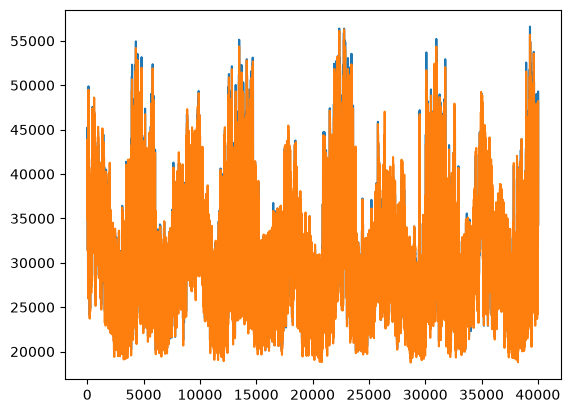

In [22]:
import matplotlib.pyplot as plt

plt.plot(y_test)
plt.plot(pred_test)

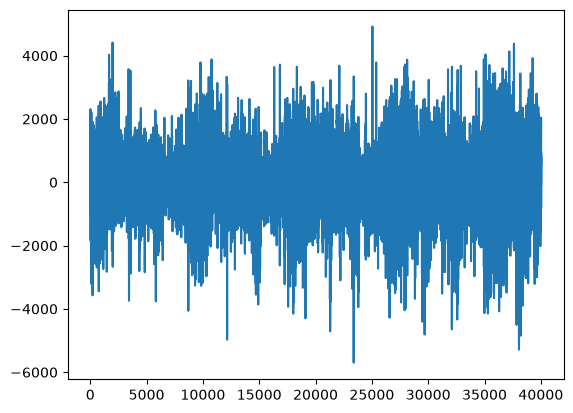

In [23]:
plt.plot(residuals)